In [1]:
import h5py

# Open the file
with h5py.File('../Data/eos_run_013050_000.hdf5', 'r') as f:
    # Print all root keys (groups and datasets)
    print(list(f.keys()))


['event', 'meta']


In [2]:
with h5py.File('../Data/eos_run_013050_000.hdf5', 'r') as f:
    print(list(f['event'].keys()))

['caen', 'id', 'key', 'muon', 'ptb', 'tv_nsec', 'tv_sec', 'type']


In [5]:
import h5py

with h5py.File('../Data/eos_run_013050_000.hdf5', 'r') as f:
    ids = f['event']['id'][()]   # load the dataset
    print(ids)

[   0    1    2 ... 8642 8643 8644]


In [6]:
import h5py
with h5py.File('../Data/eos_run_013050_000.hdf5', 'r') as f:
    print(f['event'].keys())
    print(f['event']['ptb'].keys())

<KeysViewHDF5 ['caen', 'id', 'key', 'muon', 'ptb', 'tv_nsec', 'tv_sec', 'type']>
<KeysViewHDF5 ['ptb_status', 'timestamp', 'trigger_word', 'word_type']>


In [8]:
import h5py
with h5py.File('../Data/eos_run_013050_000.hdf5', 'r') as f:
    print(f['event'].keys())
    print(f['event']['ptb'].keys())

<KeysViewHDF5 ['caen', 'id', 'key', 'muon', 'ptb', 'tv_nsec', 'tv_sec', 'type']>
<KeysViewHDF5 ['ptb_status', 'timestamp', 'trigger_word', 'word_type']>


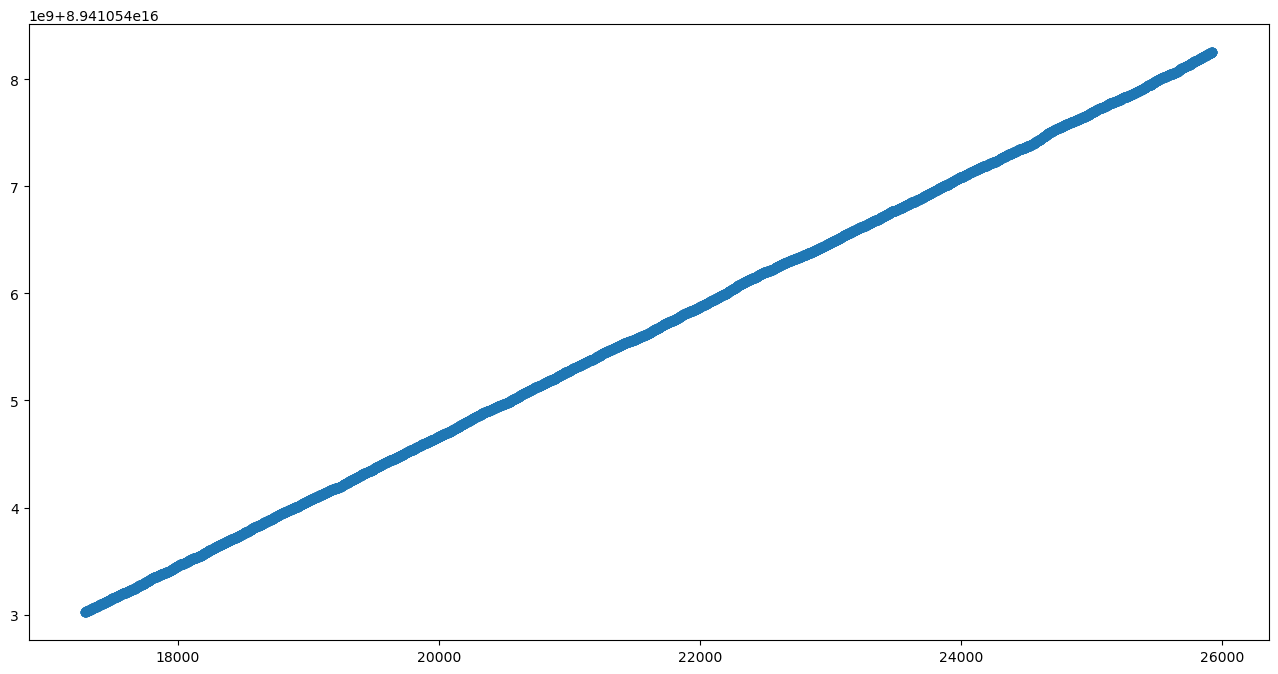

In [62]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

with h5py.File('../Data/eos_run_013050_000.hdf5', 'r') as f:
    event_id = f['event']['id'][()]
    ptb_ts = f['event']['ptb']['timestamp'][()]
    event_id = event_id[np.where(ptb_ts != 0)]
    event_id = event_id[np.where(event_id != 0)]
    event_id = event_id[np.where(event_id < 2e8)]
    ptb_ts = ptb_ts[np.where(ptb_ts != 0)]
    ptb_ts = ptb_ts[np.where(event_id != 0)]
    ptb_ts = ptb_ts[np.where(event_id < 2e8)]

#print(len(event_id), len(ptb_ts))
#print(event_id[3180:3200],ptb_ts[3180:3200])

#with h5py.File('../Data/eos_run_013050_001.hdf5', 'r') as f:
#    event_id_1 = f['event']['id'][()]
#    ptb_ts_1 = f['event']['ptb']['timestamp'][()]

#print(type(event_id))
#print(type(ptb_ts))

plt.figure(figsize=(16, 8))
plt.plot(event_id,ptb_ts,'-o')
#plt.plot(event_id_1,ptb_ts_1,'.r')
plt.show()




===== File 000 =====
index_in_file=0, event_id=0, ptb_ts=89410532327482430, failed: event_id == 0

===== File 001 =====
index_in_file=4963, event_id=54330156, ptb_ts=4031064624868243437, failed: ptb_ts >= 1e17, event_id >= 1e6
index_in_file=4964, event_id=942946353, ptb_ts=89410540743953930, failed: event_id >= 1e6

===== File 002 =====
index_in_file=3187, event_id=20473, ptb_ts=0, failed: ptb_ts == 0
index_in_file=3188, event_id=942880824, ptb_ts=89410544954826462, failed: event_id >= 1e6
index_in_file=3189, event_id=20474, ptb_ts=0, failed: ptb_ts == 0
index_in_file=3190, event_id=0, ptb_ts=89410544954826492, failed: event_id == 0

===== File 003 =====
index_in_file=4656, event_id=30583, ptb_ts=4099182647283562687, failed: ptb_ts >= 1e17

===== File 004 =====
index_in_file=7275, event_id=937048025, ptb_ts=0, failed: ptb_ts == 0, event_id >= 1e6
index_in_file=7304, event_id=41876, ptb_ts=184087430834881167, failed: ptb_ts >= 1e17
index_in_file=7305, event_id=944257075, ptb_ts=8941055

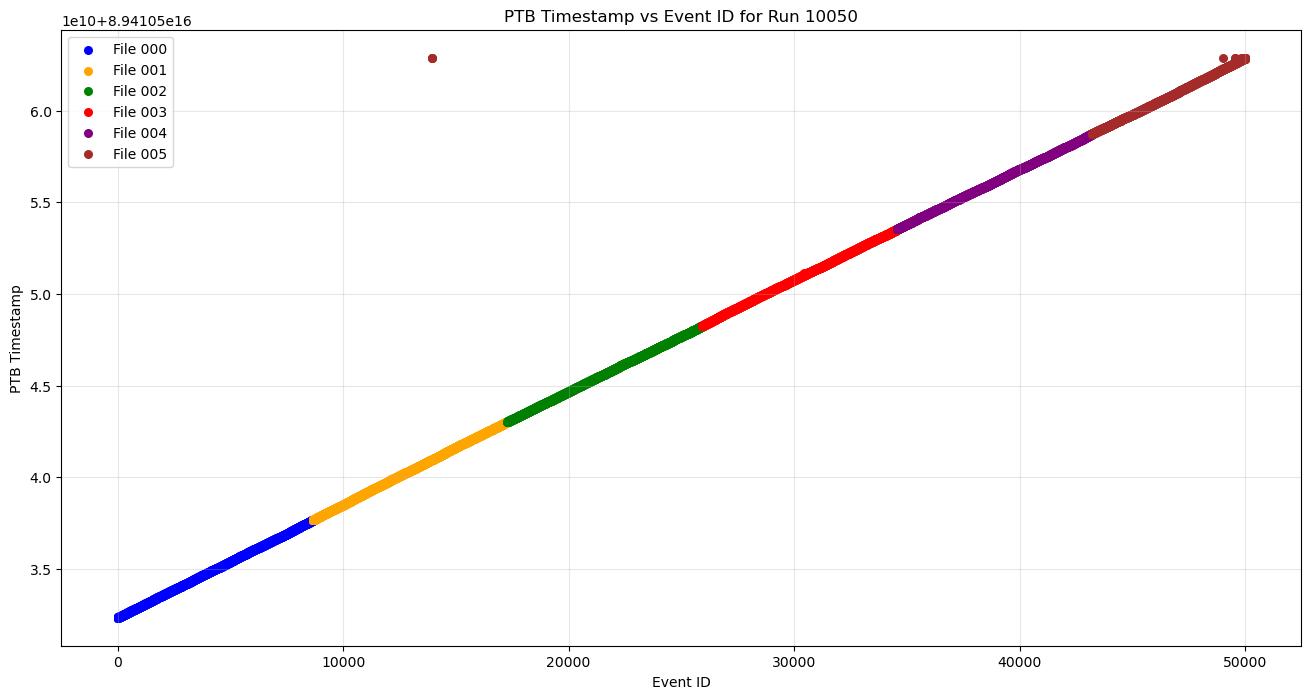

In [89]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

for i in range(6):
    filename = f'../Data/eos_run_013050_{i:03d}.hdf5'

    with h5py.File(filename, 'r') as f:
        event_id = f['event']['id'][()]
        ptb_ts = f['event']['ptb']['timestamp'][()]

    cut = (
        (ptb_ts != 0) &
        (ptb_ts < 1e17) &
        (event_id != 0) &
        (event_id < 1e6)
    )

    print(f"\n===== File {i:03d} =====")

    for idx in np.where(~cut)[0]:

        reasons = []

        if ptb_ts[idx] == 0:
            reasons.append("ptb_ts == 0")
            
        if ptb_ts[idx] >= 1e17:
            reasons.append("ptb_ts >= 1e17")

        if event_id[idx] == 0:
            reasons.append("event_id == 0")

        if event_id[idx] >= 1e6:
            reasons.append("event_id >= 1e6")

        print(
            f"index_in_file={idx}, "
            f"event_id={event_id[idx]}, "
            f"ptb_ts={ptb_ts[idx]}, "
            f"failed: {', '.join(reasons)}"
        )

    globals()[f'event_id_{i}'] = event_id[cut]
    globals()[f'ptb_ts_{i}'] = ptb_ts[cut]

plt.figure(figsize=(16, 8))

colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

for i in range(6):
    event_id = globals()[f'event_id_{i}']
    ptb_ts   = globals()[f'ptb_ts_{i}']

    plt.scatter(
        event_id,
        ptb_ts,
        s=30,
        color=colors[i],
        label=f'File {i:03d}'
    )

plt.xlabel('Event ID')
plt.ylabel('PTB Timestamp')
plt.title('PTB Timestamp vs Event ID for Run 10050')
plt.legend()
plt.grid(alpha=0.3)

#plt.xlim(48000,50100)
#plt.ylim(6.15e10+8.94105e16,6.3e10+8.94105e16)
plt.show()



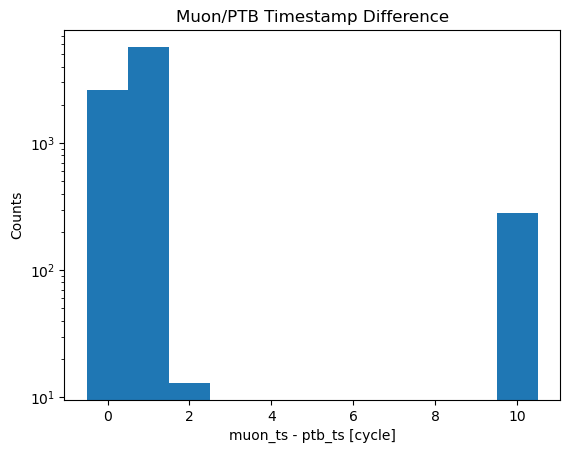

In [20]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

filename = '../Data/run8058/eos_run_008058_001.hdf5'

with h5py.File(filename, 'r') as f:
    muon_ts = f['event']['muon']['timestamp'][()]
    ptb_ts = f['event']['ptb']['timestamp'][()]
    muon_status = f['event']['muon']['muon_status'][()]
    ptb_status = f['event']['ptb']['ptb_status'][()]

ptb_t0 = ptb_ts[0]
muon_t0 = muon_ts[0]

# Quantity you want:
# muon_ts - (ptb_ts - ptb_t0)
dt = (muon_ts-muon_t0) - (ptb_ts - ptb_t0)

# Put everything above 1000 into the 1000 bin
dt_clipped = np.clip(dt, 0, 10)

plt.figure()
plt.hist(dt_clipped, bins=np.arange(-0.5,11.5))
plt.xlabel('muon_ts - ptb_ts [cycle]')
plt.ylabel('Counts')
plt.title('Muon/PTB Timestamp Difference')
plt.yscale('log')
#plt.xscale('log')
plt.show()

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

filename = '../Data/run8058/eos_run_008058_000.hdf5'

with h5py.File(filename, 'r') as f:
    muon_ts = f['event']['muon']['timestamp'][()]
    ptb_ts = f['event']['ptb']['timestamp'][()]
    muon_status = f['event']['muon']['muon_status'][()]
    ptb_status = f['event']['ptb']['ptb_status'][()]

ptb_t0 = ptb_ts[0]
muon_t0 = muon_ts[0]

# Quantity you want:
# muon_ts - (ptb_ts - ptb_t0)
dt = (muon_ts-muon_t0) - (ptb_ts - ptb_t0)

# Put everything above 1000 into the 1000 bin
dt_clipped = np.clip(dt, 0, 10)

plt.figure()
plt.hist(dt_clipped, bins=np.arange(-0.5,11.5))
plt.xlabel('muon_ts - ptb_ts [cycle]')
plt.ylabel('Counts')
plt.title('Muon/PTB Timestamp Difference')
plt.yscale('log')
#plt.xscale('log')
plt.show()

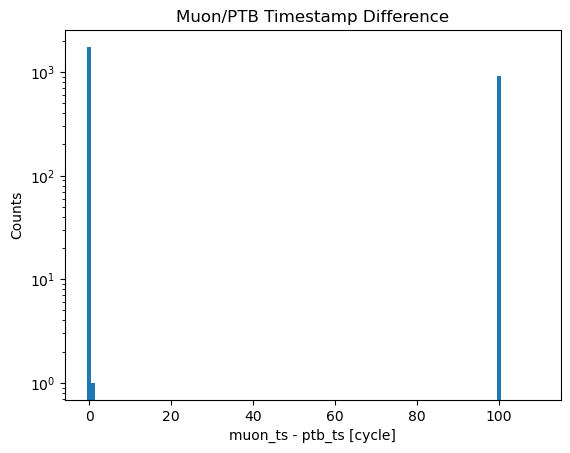

In [25]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

filename = '../Data/run8058/eos_run_008058_002.hdf5'

with h5py.File(filename, 'r') as f:
    muon_ts = f['event']['muon']['timestamp'][()]
    ptb_ts = f['event']['ptb']['timestamp'][()]
    muon_status = f['event']['muon']['muon_status'][()]
    ptb_status = f['event']['ptb']['ptb_status'][()]

ptb_t0 = ptb_ts[27]
muon_t0 = muon_ts[27]

# Quantity you want:
# muon_ts - (ptb_ts - ptb_t0)
dt = (muon_ts-muon_t0) - (ptb_ts - ptb_t0)

# Put everything above 1000 into the 1000 bin
dt_clipped = np.clip(dt, 0, 100)

plt.figure()
plt.hist(dt_clipped, bins=np.arange(-0.5,110.5))
plt.xlabel('muon_ts - ptb_ts [cycle]')
plt.ylabel('Counts')
plt.title('Muon/PTB Timestamp Difference')
plt.yscale('log')
#plt.xscale('log')
plt.show()

In [6]:
import h5py

with h5py.File('../Data/run8058/eos_run_008058_000.hdf5', 'r') as f:
    keys = f['event']['key'][()]   # load the dataset
    print(keys)

[        0        13      9538 ... 997106111 997250476 997250476]


In [23]:
import h5py

with h5py.File('eos_run_007394_000.hdf5', 'r') as f:
    print(list(f['event']['caen']['19857'].keys()))

['ch0', 'ch1', 'ch10', 'ch11', 'ch12', 'ch13', 'ch14', 'ch15', 'ch2', 'ch3', 'ch4', 'ch5', 'ch6', 'ch7', 'ch8', 'ch9', 'counters', 'exttimetags', 'timetags']


In [24]:
import h5py

with h5py.File('eos_run_007394_000.hdf5', 'r') as f:
  #  print(list(f['event']['caen']['19857']['counter'].keys()))

    
    print(f['event']['caen']['19857']['counters'][()])

[   0   28   76  105  135  285  354  392  417  498  565  652  702  724
  809  837  882  971  973 1007 1035 1066 1162 1176 1256 1309 1341 1362
 1445 1518 1573 1660 1809 1856 1907]
